# 4 · Street level: accuracy by pixel size and accumulation time

`run.py city`: a 25.6 km city with 100 m, 1-min truth; a C-band radar at 800 m, an X-band radar
at 200 m (attenuation corrected), 80-300 links, 2-12 gauges, 20-150 PWS. Every map is made on a
200 m grid every 5 min and scored at 100 m (each 200 m pixel read for its four street pixels)
up to 6.4 km, and at 5 to 60 min - and at 200 m by the distance to the nearest link.

In [1]:
import sys
import warnings
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent / "src"))
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, Markdown, display

from core import viz_style as vs
%matplotlib inline
vs.use_style()
pd.set_option("display.width", 160)
FIG = Path("../results/figures")
TAB = Path("../results/tables")

from synthetic_testbed import city

In [2]:
d = city.load()
print(d.scenario.nunique(), "scenarios:", d.groupby("scenario").model.first().value_counts().to_dict())
a = d[d.region == "all"]

9 scenarios: {'cascade': 2, 'rainfarm': 2, 'convective_cells': 2, 'scale_free': 2, 'clustered_storms': 1}


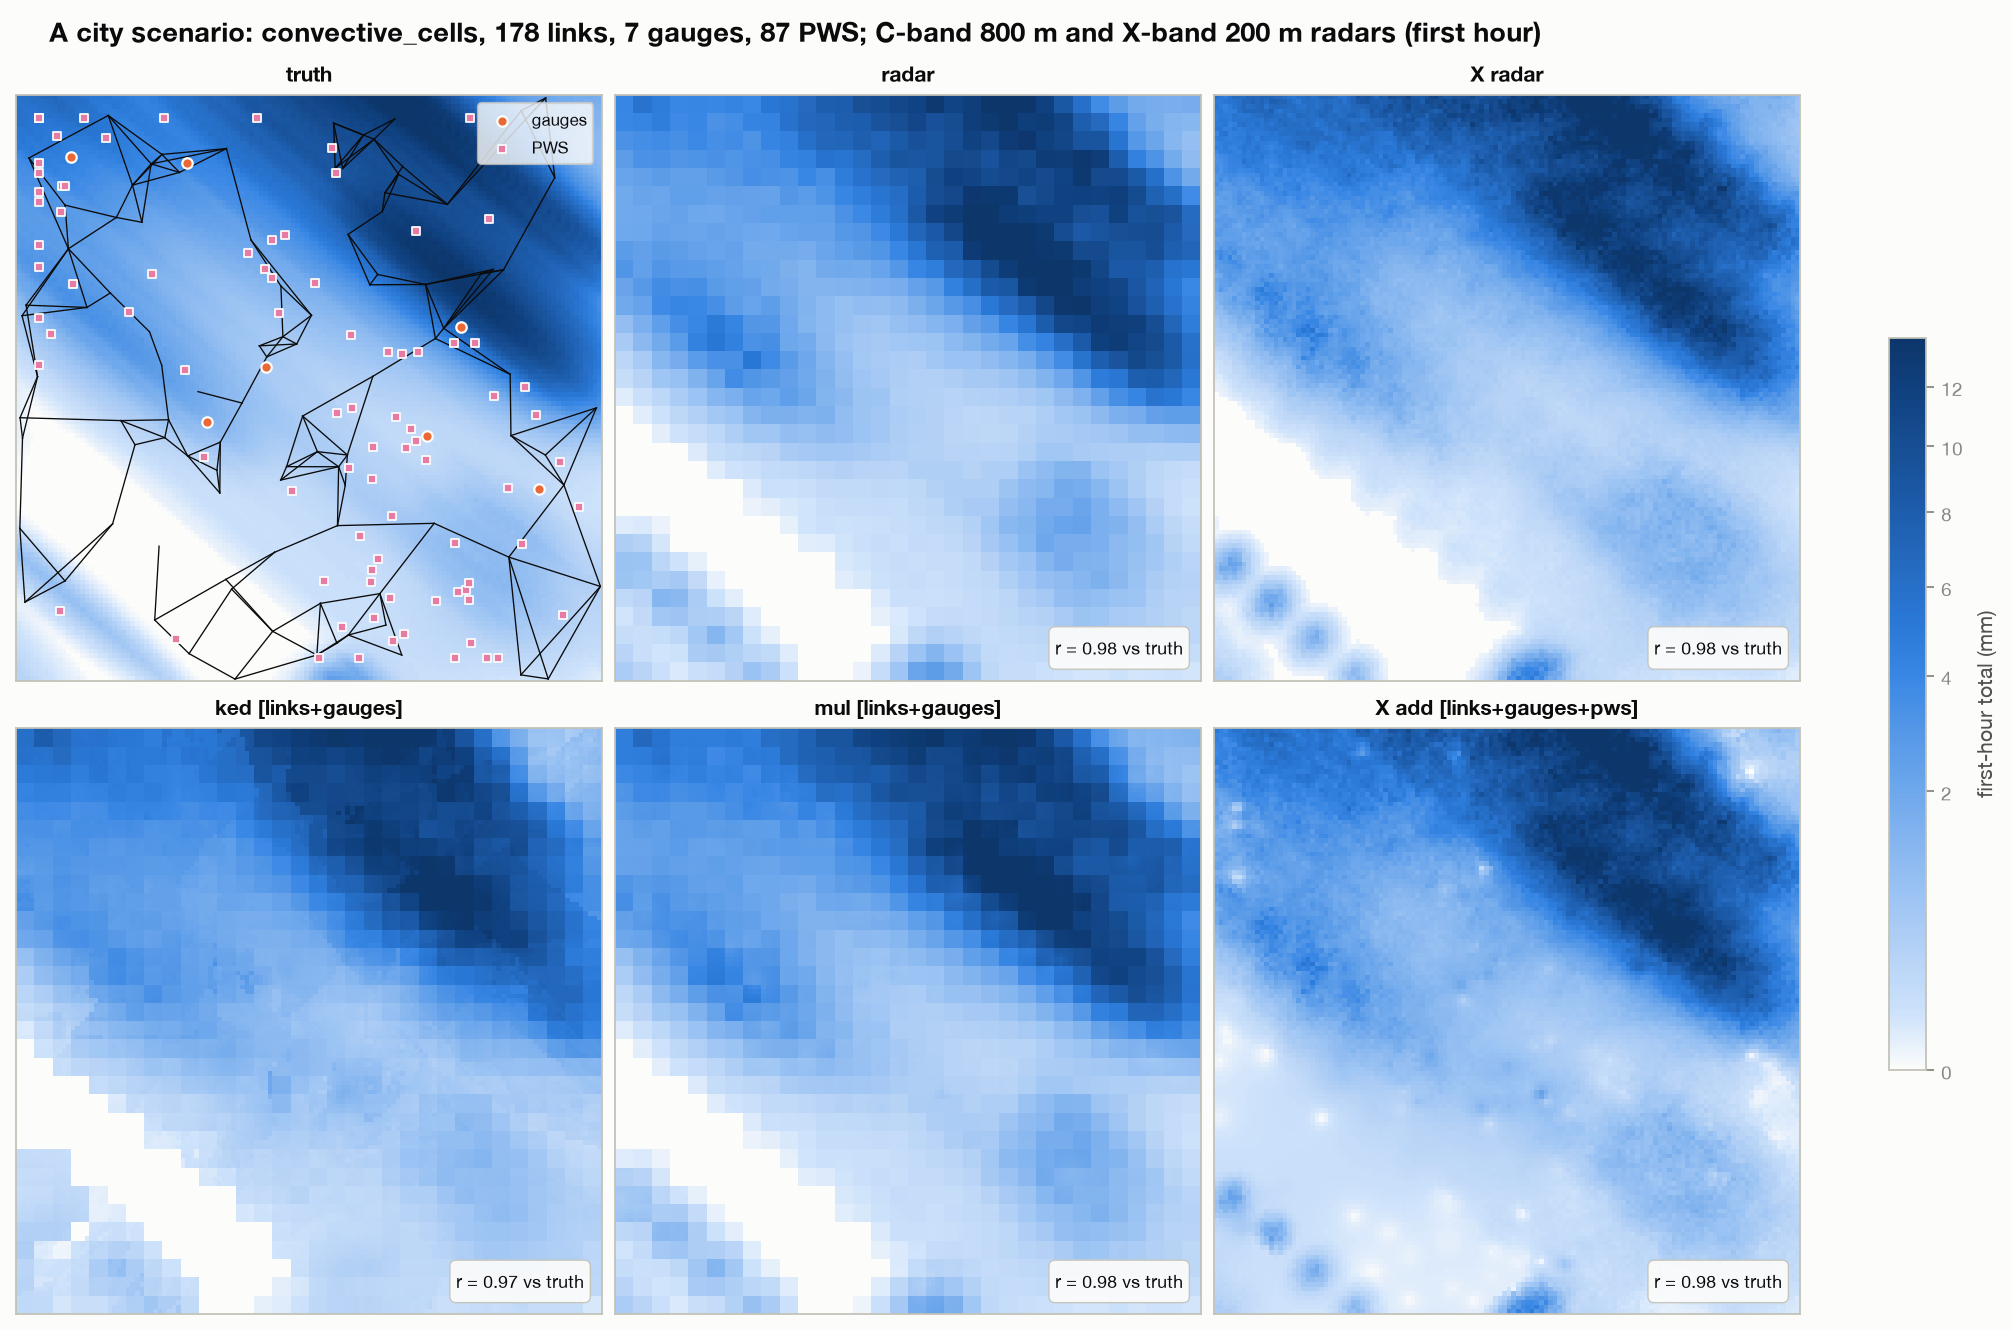

In [3]:
display(Image(str(FIG / "fig11_city_example.png")))

## Error against pixel size and accumulation time

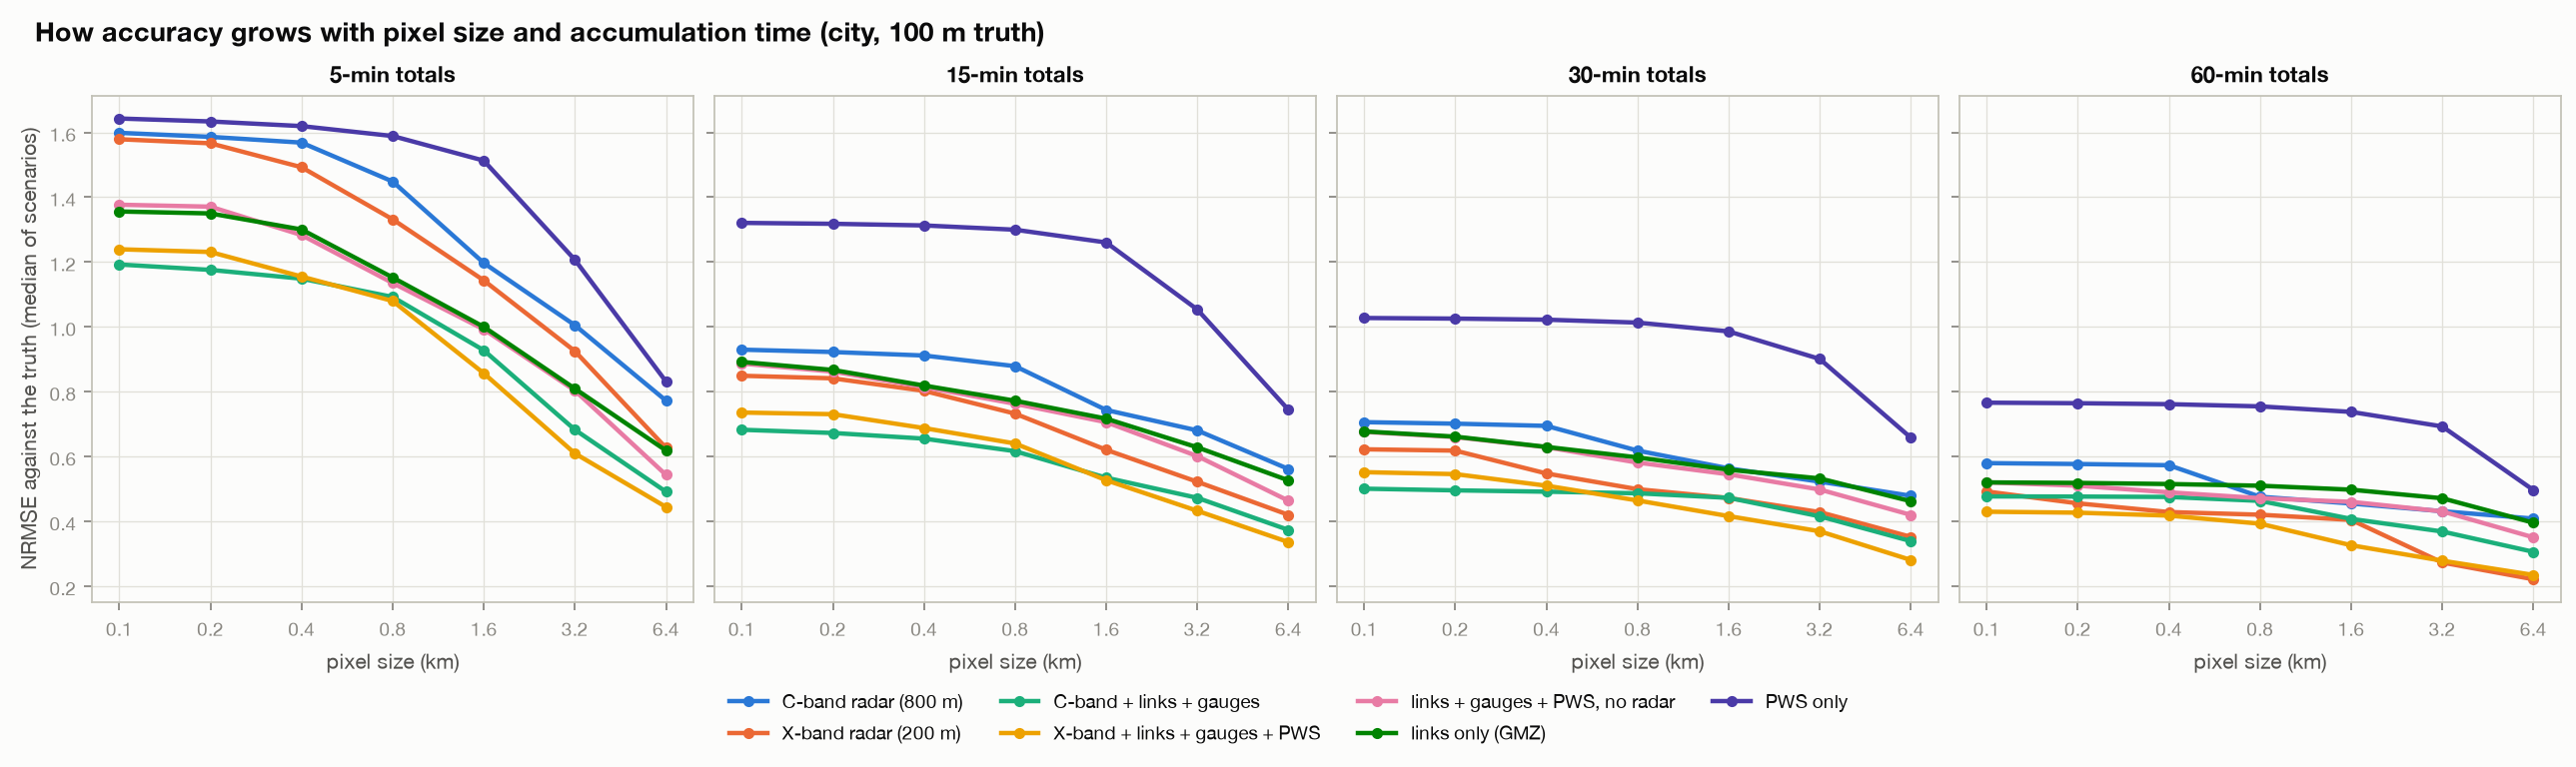

In [4]:
display(Image(str(FIG / "fig08_scales.png")))

In [5]:
show = ["radar", "X radar", "add [links+gauges]", "X add [links+gauges]", "X add [links+gauges+pws]",
        "ked [links+gauges]", "idw links+gauges+pws", "idw pws", "gmz links"]
t = a[a.method.isin(show) & a.space_km.isin([0.1, 0.4, 1.6, 6.4]) & a.time_min.isin([5, 60])]
t.pivot_table(index="method", columns=["time_min", "space_km"], values="nrmse", aggfunc="median").round(2)

time_min                  5.0                     60.0                  
space_km                   0.1   0.4   1.6   6.4   0.1   0.4   1.6   6.4
method                                                                  
X add [links+gauges+pws]  1.24  1.16  0.86  0.44  0.43  0.42  0.33  0.23
X add [links+gauges]      1.33  1.23  0.91  0.48  0.46  0.45  0.37  0.30
X radar                   1.58  1.49  1.14  0.63  0.49  0.43  0.40  0.22
add [links+gauges]        1.19  1.15  0.93  0.49  0.48  0.48  0.41  0.31
gmz links                 1.36  1.30  1.00  0.62  0.52  0.52  0.50  0.40
idw links+gauges+pws      1.38  1.28  0.99  0.54  0.52  0.49  0.46  0.35
idw pws                   1.64  1.62  1.51  0.83  0.77  0.76  0.74  0.50
ked [links+gauges]        1.12  1.06  0.89  0.51  0.46  0.45  0.41  0.34
radar                     1.60  1.57  1.20  0.77  0.58  0.57  0.46  0.41

CSI at 1 mm/h (where does it rain?) at the same scales:

In [6]:
t.pivot_table(index="method", columns=["time_min", "space_km"], values="csi", aggfunc="median").round(2)

time_min                  5.0                     60.0                  
space_km                   0.1   0.4   1.6   6.4   0.1   0.4   1.6   6.4
method                                                                  
X add [links+gauges+pws]  0.67  0.68  0.69  0.76  0.75  0.75  0.77  0.89
X add [links+gauges]      0.64  0.65  0.67  0.75  0.74  0.74  0.78  0.80
X radar                   0.65  0.66  0.68  0.78  0.83  0.83  0.86  1.00
add [links+gauges]        0.66  0.66  0.68  0.74  0.75  0.75  0.78  0.78
gmz links                 0.53  0.53  0.55  0.62  0.66  0.66  0.68  0.75
idw links+gauges+pws      0.55  0.56  0.59  0.66  0.69  0.69  0.72  0.76
idw pws                   0.42  0.42  0.43  0.52  0.70  0.70  0.71  0.76
ked [links+gauges]        0.63  0.64  0.67  0.76  0.76  0.76  0.77  0.84
radar                     0.64  0.64  0.69  0.78  0.84  0.84  0.88  0.94

## Near the links

NRMSE of 60-min totals at 200 m, by distance from the nearest link:

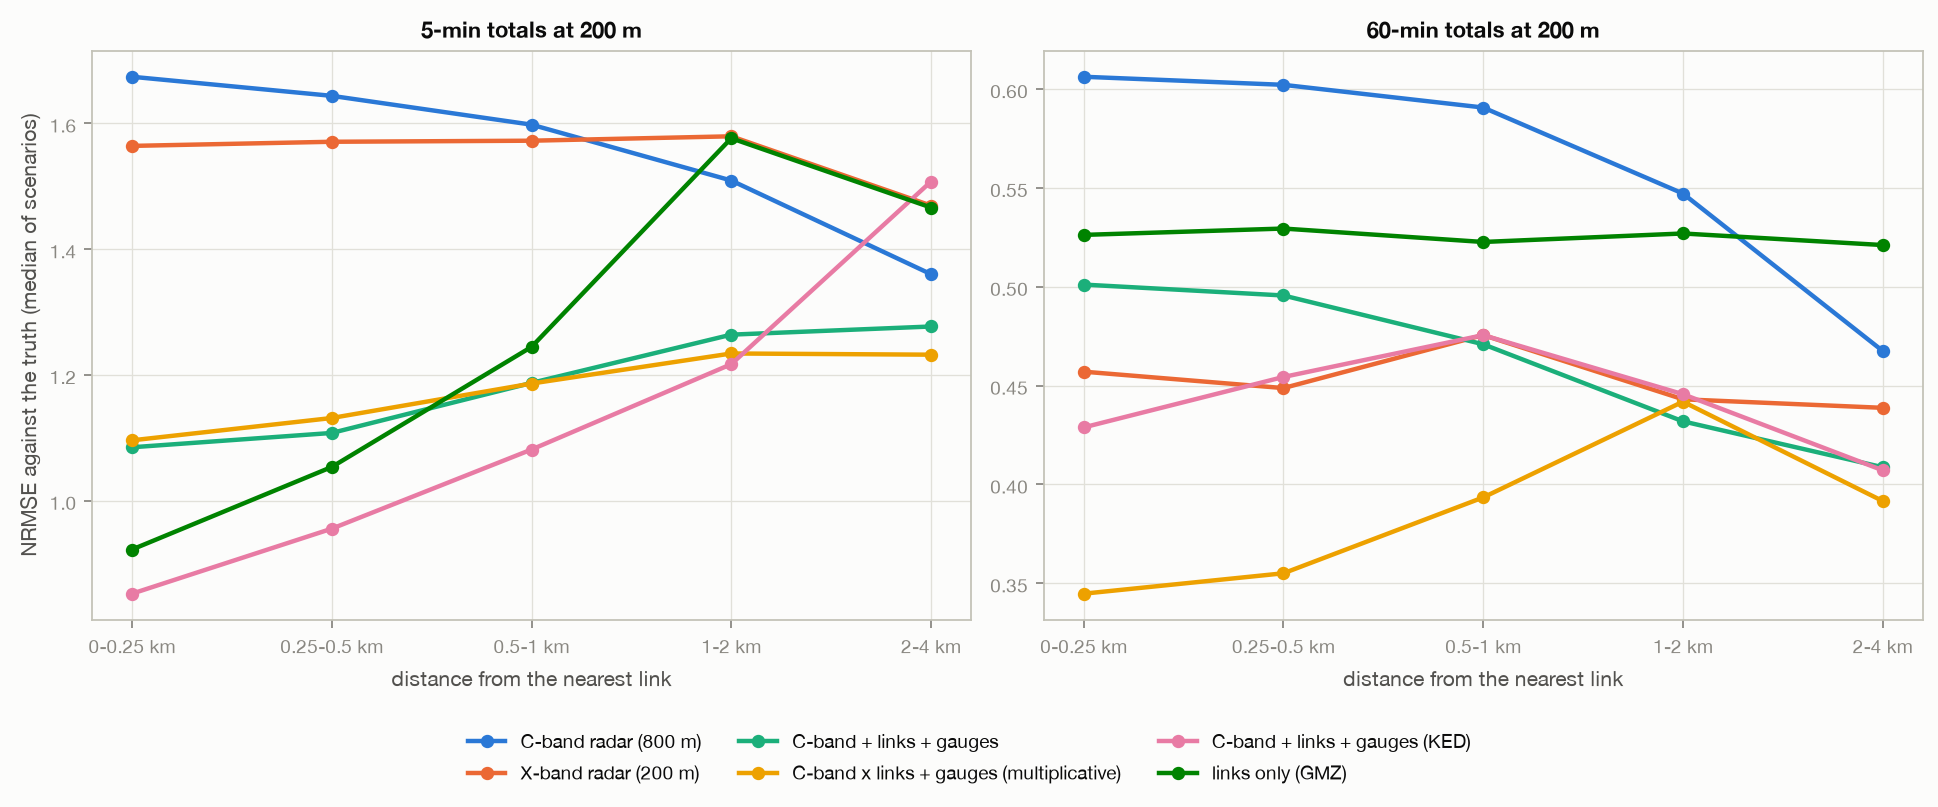

region,0-0.25 km,0.25-0.5 km,0.5-1 km,1-2 km,2-4 km,>4 km
method,,,,,,
radar,0.61,0.60,0.59,0.55,0.47,0.22
add [links],0.50,0.50,0.48,0.45,0.44,0.21
add [links+gauges],0.50,0.50,0.47,0.43,0.41,0.21
ked [links+gauges],0.43,0.45,0.48,0.45,0.41,0.34
gmz links,0.53,0.53,0.52,0.53,0.52,0.65
X radar,0.46,0.45,0.48,0.44,0.44,0.35


In [7]:
display(Image(str(FIG / "fig09_link_distance.png")))
b = d[(d.region != "all") & (d.time_min == 60)]
b.pivot_table(index="method", columns="region", values="nrmse", aggfunc="median")[
    sorted(set(b.region), key=lambda r: b[b.region == r].band_lo.iloc[0])].loc[
    [m for m in ["radar", "add [links]", "add [links+gauges]", "ked [links+gauges]", "gmz links", "X radar"] if m in set(b.method)]].round(2)